In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Load the CSV
csv_path = Path('/home/amma/LLM-TIME/fairness/analysis_results').glob('advanced_metrics_raw_*.csv')
latest_csv = sorted(csv_path)[-1]
print(f"Loading: {latest_csv.name}")

df = pd.read_csv(latest_csv)
print(f"\nLoaded {len(df)} records")
print(f"\nDataset shape: {df.shape}")
df.head(10)

Loading: advanced_metrics_raw_window_majority_20260104_181211.csv

Loaded 50 records

Dataset shape: (50, 10)


,context,feature,scenario,dp_gap,eo_gap,fvo,assessment,n_samples,n_groups,note
0,inference,age_inference,only,0.0326,0.3004,0.0234,❌ CRITICAL (High EO Gap),281088,3,Calculated from actual predictions
1,inference,age_trained,denoised,0.0235,0.6231,0.0054,❌ CRITICAL (High EO Gap),187392,3,Calculated from actual predictions
2,inference,age_trained,noisy,0.0362,0.1568,0.0122,⚠️ MODERATE CONCERNS,187392,3,Calculated from actual predictions
3,inference,age_trained,standard,0.0377,0.1733,0.0112,⚠️ MODERATE CONCERNS,187392,3,Calculated from actual predictions
4,inference,cohort_inference,only,0.0086,0.0292,0.0071,✅ FAIR,281088,2,Calculated from actual predictions
5,inference,cohort_trained,denoised,0.0017,0.0327,0.0020,✅ FAIR,187392,2,Calculated from actual predictions
6,inference,cohort_trained,noisy,0.0096,0.0243,0.0049,✅ FAIR,187392,2,Calculated from actual predictions
7,inference,cohort_trained,standard,0.0118,0.0011,0.0064,✅ FAIR,187392,2,Calculated from actual predictions
8,inference,gender_inference,only,0.0238,0.2522,0.0105,❌ CRITICAL (High EO Gap),281088,2,Calculated from actual predictions
9,inference,gender_trained,denoised,0.0244,0.1575,0.0078,⚠️ MODERATE CONCERNS,187392,2,Calculated from actual predictions


In [2]:
# Check the structure
print("Column names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)
print(f"\nUnique contexts:")
print(df['context'].unique())
print(f"\nUnique features:")
print(df['feature'].unique())

Column names:
['context', 'feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment', 'n_samples', 'n_groups', 'note']

Data types:
context        object
feature        object
scenario       object
dp_gap        float64
eo_gap        float64
fvo           float64
assessment     object
n_samples       int64
n_groups        int64
note           object
dtype: object

Unique contexts:
['inference' 'distillation_all_patients' 'distillation_per_patient']

Unique features:
['age_inference' 'age_trained' 'cohort_inference' 'cohort_trained'
 'gender_inference' 'gender_trained' 'pump_model' 'sensor_band' 'age'
 'cohort' 'gender']


## Summary Statistics by Context

In [3]:
# Summary statistics by context
metrics = ['dp_gap', 'eo_gap', 'fvo']

for metric in metrics:
    print(f"\n{'='*80}")
    print(f"{metric.upper()} Summary")
    print(f"{'='*80}")
    summary = df.groupby('context')[metric].agg(['min', 'max', 'mean', 'std'])
    print(summary)
    print()


DP_GAP Summary
                              min     max      mean       std
context                                                      
distillation_all_patients  0.0080  0.0336  0.020947  0.011039
distillation_per_patient   0.0105  0.0389  0.023893  0.012115
inference                  0.0017  0.0377  0.020535  0.012099


EO_GAP Summary
                              min     max      mean       std
context                                                      
distillation_all_patients  0.0053  0.2367  0.108013  0.093155
distillation_per_patient   0.0018  0.1799  0.080287  0.068349
inference                  0.0011  0.6231  0.122720  0.143717


FVO Summary
                              min     max      mean       std
context                                                      
distillation_all_patients  0.0048  0.0182  0.010240  0.005291
distillation_per_patient   0.0039  0.0168  0.009753  0.004777
inference                  0.0020  0.0234  0.008295  0.005667



## Feature-Level Analysis

In [4]:
# Extract feature names from the feature column (handle cases like 'age_inference_only' or just 'age')
def extract_feature_name(feature_str):
    """Extract the demographic feature from the feature column"""
    for feat in ['gender', 'age', 'cohort', 'pump_model', 'sensor_band']:
        if feat in feature_str.lower():
            return feat
    return None

df['demographic_feature'] = df['feature'].apply(extract_feature_name)

print("Features identified:")
print(df['demographic_feature'].unique())

# Summary by demographic feature
print(f"\n{'='*80}")
print("Summary by Demographic Feature")
print(f"{'='*80}\n")

feature_summary = df.groupby('demographic_feature')[['dp_gap', 'eo_gap', 'fvo']].agg(['min', 'max', 'mean'])
print(feature_summary)

Features identified:
['age' 'cohort' 'gender' 'pump_model' 'sensor_band']

Summary by Demographic Feature

                     dp_gap                   eo_gap                      fvo  \
                        min     max     mean     min     max     mean     min   
demographic_feature                                                             
age                  0.0235  0.0389  0.03396  0.1568  0.6231  0.23720  0.0054   
cohort               0.0017  0.0118  0.00901  0.0011  0.0327  0.01430  0.0020   
gender               0.0223  0.0248  0.02390  0.1010  0.2522  0.16555  0.0039   
pump_model           0.0156  0.0381  0.03245  0.0616  0.1417  0.09654  0.0036   
sensor_band          0.0017  0.0118  0.00901  0.0011  0.0327  0.01430  0.0020   

                                      
                        max     mean  
demographic_feature                   
age                  0.0234  0.01506  
cohort               0.0074  0.00600  
gender               0.0105  0.00592  
pump_model

## Worst Fairness Cases (Highest Metric Values)

In [5]:
# Top 10 worst cases for each metric
print("TOP 10 WORST DP GAP (Demographic Parity Gap)\n")
worst_dp = df.nlargest(10, 'dp_gap')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment']]
print(worst_dp.to_string())

print("\n" + "="*100 + "\n")
print("TOP 10 WORST EO GAP (Equal Opportunity Gap)\n")
worst_eo = df.nlargest(10, 'eo_gap')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment']]
print(worst_eo.to_string())

print("\n" + "="*100 + "\n")
print("TOP 10 WORST FVO (Fairness Violation Objective)\n")
worst_fvo = df.nlargest(10, 'fvo')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment']]
print(worst_fvo.to_string())

TOP 10 WORST DP GAP (Demographic Parity Gap)

                     context demographic_feature          scenario  dp_gap  eo_gap     fvo            assessment
37  distillation_per_patient                 age           teacher  0.0389  0.1748  0.0168  ⚠️ MODERATE CONCERNS
35  distillation_per_patient                 age         distilled  0.0387  0.1799  0.0162  ⚠️ MODERATE CONCERNS
46  distillation_per_patient          pump_model           teacher  0.0381  0.0830  0.0157                ✅ FAIR
3                  inference                 age          standard  0.0377  0.1733  0.0112  ⚠️ MODERATE CONCERNS
44  distillation_per_patient          pump_model         distilled  0.0377  0.0895  0.0149                ✅ FAIR
15                 inference          pump_model  trained_standard  0.0368  0.0888  0.0101                ✅ FAIR
2                  inference                 age             noisy  0.0362  0.1568  0.0122  ⚠️ MODERATE CONCERNS
14                 inference          pump_model  

## Best Fairness Cases (Lowest Metric Values)

In [6]:
# Top 10 best cases (lowest values = fairest)
print("TOP 10 BEST DP GAP (lowest = fairest)\n")
best_dp = df.nsmallest(10, 'dp_gap')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment']]
print(best_dp.to_string())

print("\n" + "="*100 + "\n")
print("TOP 10 BEST EO GAP (lowest = fairest)\n")
best_eo = df.nsmallest(10, 'eo_gap')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment']]
print(best_eo.to_string())

print("\n" + "="*100 + "\n")
print("TOP 10 BEST FVO (lowest = fairest)\n")
best_fvo = df.nsmallest(10, 'fvo')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment']]
print(best_fvo.to_string())

TOP 10 BEST DP GAP (lowest = fairest)

                      context demographic_feature          scenario  dp_gap  eo_gap     fvo assessment
5                   inference              cohort          denoised  0.0017  0.0327  0.0020     ✅ FAIR
17                  inference         sensor_band  trained_denoised  0.0017  0.0327  0.0020     ✅ FAIR
25  distillation_all_patients              cohort           teacher  0.0080  0.0143  0.0059     ✅ FAIR
34  distillation_all_patients         sensor_band           teacher  0.0080  0.0143  0.0059     ✅ FAIR
23  distillation_all_patients              cohort         distilled  0.0083  0.0053  0.0060     ✅ FAIR
32  distillation_all_patients         sensor_band         distilled  0.0083  0.0053  0.0060     ✅ FAIR
4                   inference              cohort              only  0.0086  0.0292  0.0071     ✅ FAIR
16                  inference         sensor_band    inference_only  0.0086  0.0292  0.0071     ✅ FAIR
24  distillation_all_patients     

## Visualization: Metrics Across Contexts

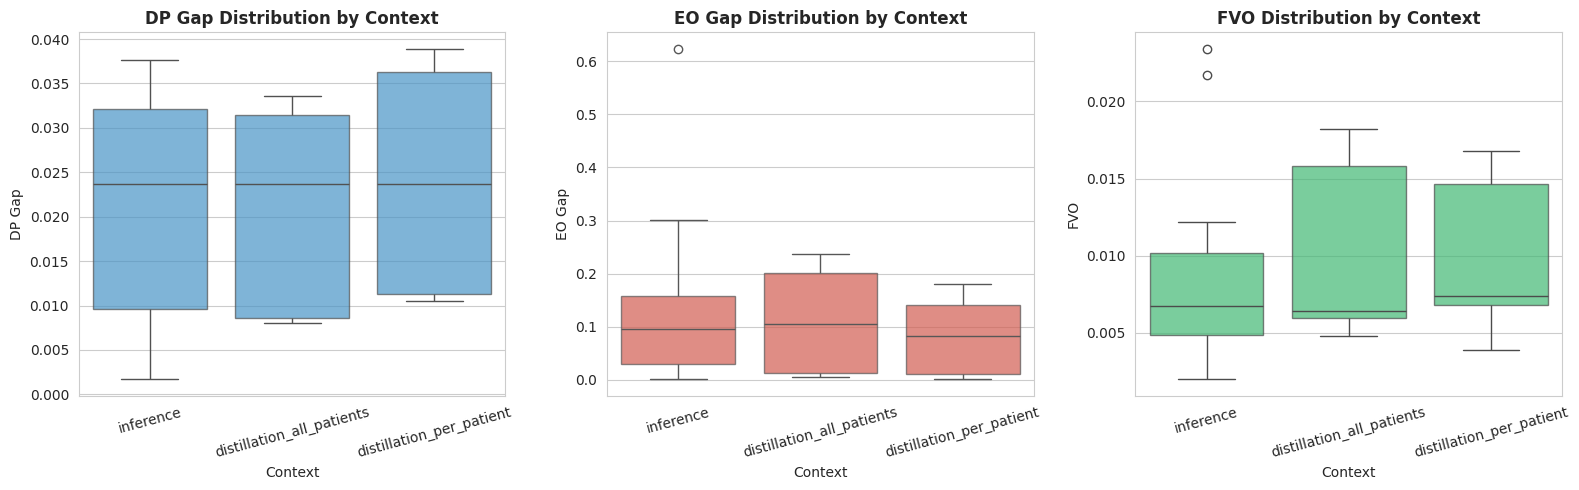

Saved: metrics_by_context_boxplot.png


In [8]:
# Box plots for each metric across contexts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['dp_gap', 'eo_gap', 'fvo']
metric_labels = ['DP Gap', 'EO Gap', 'FVO']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    box_plot = sns.boxplot(data=df, x='context', y=metric, ax=axes[idx], color=color)
    # Set alpha for the box patches
    for patch in box_plot.patches:
        patch.set_alpha(0.7)
    axes[idx].set_title(f'{label} Distribution by Context', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Context', fontsize=10)
    axes[idx].set_ylabel(label, fontsize=10)
    axes[idx].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/home/amma/LLM-TIME/fairness/analysis_results/metrics_by_context_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: metrics_by_context_boxplot.png")

## Visualization: Metrics by Feature

In [ ]:
# Bar plots for each metric by demographic feature
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    feature_data = df.groupby('demographic_feature')[metric].mean().sort_values(ascending=False)
    feature_data.plot(kind='bar', ax=axes[idx], color=color, alpha=0.7)
    axes[idx].set_title(f'Average {label} by Demographic Feature', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Demographic Feature', fontsize=10)
    axes[idx].set_ylabel(f'Average {label}', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/home/amma/LLM-TIME/fairness/analysis_results/metrics_by_feature_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: metrics_by_feature_barplot.png")

## Heatmap: Feature × Metric × Context

In [ ]:
# Create heatmap for each metric
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    # Pivot table: features × contexts
    pivot_data = df.pivot_table(
        values=metric, 
        index='demographic_feature', 
        columns='context', 
        aggfunc='mean'
    )
    
    sns.heatmap(
        pivot_data, 
        annot=True, 
        fmt='.4f', 
        cmap='RdYlGn_r', 
        ax=axes[idx],
        cbar_kws={'label': label}
    )
    axes[idx].set_title(f'{label} by Feature and Context', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Context', fontsize=10)
    axes[idx].set_ylabel('Demographic Feature', fontsize=10)

plt.tight_layout()
plt.savefig('/home/amma/LLM-TIME/fairness/analysis_results/metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: metrics_heatmap.png")

## Inference Scenario Comparison

In [ ]:
# Focus on inference scenarios
inference_df = df[df['context'] == 'inference'].copy()

print(f"Inference scenarios: {inference_df['scenario'].unique()}")
print(f"\nTotal inference records: {len(inference_df)}\n")

# Compare inference_only vs trained scenarios
print("="*100)
print("INFERENCE SCENARIO COMPARISON")
print("="*100)

for feature in inference_df['demographic_feature'].unique():
    print(f"\n{feature.upper()}:")
    feature_data = inference_df[inference_df['demographic_feature'] == feature].copy()
    feature_data = feature_data.sort_values('scenario')
    
    print(feature_data[['scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment']].to_string(index=False))

## Distillation Impact Analysis

In [ ]:
# Analyze distillation impact
distillation_contexts = df[df['context'].str.contains('distillation')]['context'].unique()

for context in distillation_contexts:
    print(f"\n{'='*100}")
    print(f"{context.upper()}")
    print(f"{'='*100}")
    
    context_df = df[df['context'] == context].copy()
    
    for feature in context_df['demographic_feature'].unique():
        print(f"\n{feature.upper()}:")
        feature_data = context_df[context_df['demographic_feature'] == feature].copy()
        feature_data = feature_data.sort_values('scenario')
        
        print(feature_data[['scenario', 'dp_gap', 'eo_gap', 'fvo', 'assessment']].to_string(index=False))

## Critical Fairness Issues

In [ ]:
# Find critical and moderate concern cases
critical = df[df['assessment'].str.contains('CRITICAL', na=False)]
moderate = df[df['assessment'].str.contains('MODERATE', na=False)]
minor = df[df['assessment'].str.contains('MINOR', na=False)]
fair = df[df['assessment'].str.contains('FAIR', na=False)]

print("FAIRNESS ASSESSMENT SUMMARY")
print(f"\nCRITICAL: {len(critical)} cases")
print(critical[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo']].to_string())

print(f"\nMODERATE: {len(moderate)} cases")
print(f"\nMINOR: {len(minor)} cases")
print(f"\nFAIR: {len(fair)} cases")

# Assessment breakdown
print(f"\n\nAssessment Breakdown:")
assessment_counts = df['assessment'].value_counts()
print(assessment_counts)

## Context Performance Ranking

In [ ]:
# Rank contexts by fairness
print("\nCONTEXT FAIRNESS RANKING (lower metrics = better)\n")

context_stats = df.groupby('context')[['dp_gap', 'eo_gap', 'fvo']].agg(['mean', 'median'])

print("\nAVERAGE DP GAP (lower is better):")
dp_ranking = df.groupby('context')['dp_gap'].mean().sort_values()
for i, (context, value) in enumerate(dp_ranking.items(), 1):
    print(f"  {i}. {context}: {value:.4f}")

print("\nAVERAGE EO GAP (lower is better):")
eo_ranking = df.groupby('context')['eo_gap'].mean().sort_values()
for i, (context, value) in enumerate(eo_ranking.items(), 1):
    print(f"  {i}. {context}: {value:.4f}")

print("\nAVERAGE FVO (lower is better):")
fvo_ranking = df.groupby('context')['fvo'].mean().sort_values()
for i, (context, value) in enumerate(fvo_ranking.items(), 1):
    print(f"  {i}. {context}: {value:.4f}")

## Export Summary Tables

In [ ]:
# Create and export summary tables
output_dir = Path('/home/amma/LLM-TIME/fairness/analysis_results')

# Summary by context and feature
context_feature_summary = df.groupby(['context', 'demographic_feature'])[['dp_gap', 'eo_gap', 'fvo']].mean()
context_feature_summary.to_csv(output_dir / 'summary_by_context_and_feature.csv')
print("Saved: summary_by_context_and_feature.csv")

# Worst cases summary
worst_cases = pd.concat([
    df.nlargest(5, 'dp_gap')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo']].assign(reason='High DP Gap'),
    df.nlargest(5, 'eo_gap')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo']].assign(reason='High EO Gap'),
    df.nlargest(5, 'fvo')[['context', 'demographic_feature', 'scenario', 'dp_gap', 'eo_gap', 'fvo']].assign(reason='High FVO')
])
worst_cases.to_csv(output_dir / 'worst_cases_summary.csv', index=False)
print("Saved: worst_cases_summary.csv")

# Assessment distribution
assessment_dist = df.groupby(['context', 'assessment']).size().unstack(fill_value=0)
assessment_dist.to_csv(output_dir / 'assessment_distribution.csv')
print("Saved: assessment_distribution.csv")

print("\nAll summary files saved to:", output_dir)